# Agiles Programmierprojekt – Bengaluru Immobilienpreis-Analyse

Dieses Notebook führt die gesamte Analyse-Pipeline Schritt für Schritt aus.
Jeder Abschnitt entspricht einem Skript im `src/`-Ordner und einem Abschnitt
der Aufgabendefinition.

**Voraussetzung:** Ein lokaler MySQL-Server läuft, das Schema aus
`sql/schema.sql` wurde angelegt, und `config.py` enthält die korrekten
Zugangsdaten (am besten über die Umgebungsvariable `DB_PASSWORD`).

Alle Diagramme und Tabellen werden zusätzlich im Ordner `/output` gespeichert,
sodass sie direkt für die Präsentation/Dokumentation weiterverwendet werden
können.

## Setup

In [1]:
import sys, os
import subprocess

# Install all required packages in this Jupyter environment
packages = [
    "pandas", "numpy", "scipy", "scikit-learn",
    "matplotlib", "seaborn", "sqlalchemy", "pymysql", "joblib"
]

for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("✅ All packages installed in Jupyter environment!")

sys.path.insert(0, os.path.abspath('.'))

import warnings
warnings.filterwarnings('ignore')

from notebook_helpers import load_step
from IPython.display import Image, display
from config import OUTPUT_DIR

def show(*filenames):
    for fname in filenames:
        display(Image(filename=f'{OUTPUT_DIR}/{fname}'))

✅ All packages installed in Jupyter environment!


## Schritt 1: Rohdaten in MySQL speichern\n\n*Speicherung des gesamten Datensatzes zunächst in MySQL.*

In [2]:
step1 = load_step('01_load_data.py')
step1.main()

=== Schritt 1: Rohdaten in MySQL speichern ===

✅ Verbindung zur MySQL-Datenbank erfolgreich.
📄 CSV geladen: 13320 Zeilen, 9 Spalten
✅ 13320 Zeilen in Tabelle 'property_listings' eingefügt.

Fertig. Die Rohdaten liegen jetzt vollständig in MySQL vor.


## Schritt 2: Daten bereinigen\n\n*Bereinigung von total_sqft, fehlenden Werten, Ausreißern; Feature Engineering.*

In [3]:
step2 = load_step('02_clean_data.py')
step2.main()

=== Schritt 2: Daten bereinigen ===

📄 13320 Zeilen aus MySQL geladen.

--- Datenbereinigungs-Report ---
  total_sqft_unparsable: 0
  size_missing_or_unparsable: 16
  location_missing_dropped: 1
  bath_missing_imputed: 57
  balcony_missing_imputed: 593
  total_sqft_implausible_removed: 21
  unrealistic_sqft_per_bhk_removed: 748
  price_per_sqft_outliers_removed: 769
  unrealistic_bath_count_removed: 7
  exact_duplicates_removed: 0
  rare_locations_grouped_to_other: 981

Zeilen vorher: 13320  ->  Zeilen nachher: 11758 (1562 entfernt, 11.7%)

✅ Bereinigte Daten gespeichert unter: d:\learning\hsh2\final_project\DataScienceProjekt\output/cleaned_data.csv

Spalten im bereinigten Datensatz:
['id', 'area_type', 'availability', 'location', 'size', 'society', 'total_sqft', 'bath', 'balcony', 'price', 'created_at', 'total_sqft_clean', 'bhk', 'price_per_sqft', 'location_grouped']

Vorschau:
   id             area_type   availability                  location  \
0   1  Super built-up  Area        

## Schritt 3: Deskriptive Statistik und Datenverständnis

In [4]:
step3 = load_step('03_descriptive_stats.py')
step3.main()

=== Schritt 3: Deskriptive Statistik und Datenverständnis ===

📄 Bereinigte Daten geladen: 11758 Zeilen, 15 Spalten

--- Lageparameter und Streuungsmaße ---
                     mean  median   q1_25%   q3_75%      std     variance  \
total_sqft_clean  1537.68  1293.5  1110.00  1668.75   896.20    803173.12   
bath                 2.51     2.0     2.00     3.00     1.02         1.04   
balcony              1.60     2.0     1.00     2.00     0.79         0.63   
bhk                  2.60     2.0     2.00     3.00     0.93         0.87   
price              100.42    68.0    48.00   107.00   121.36     14727.84   
price_per_sqft    5958.61  5200.0  4179.62  6666.67  3201.72  10251037.89   

                    min       max  skewness  
total_sqft_clean  300.0  20000.00      5.00  
bath                1.0     16.00      2.21  
balcony             0.0      3.00     -0.02  
bhk                 1.0     16.00      2.03  
price               9.0   2912.00      8.22  
price_per_sqft    405.4  76

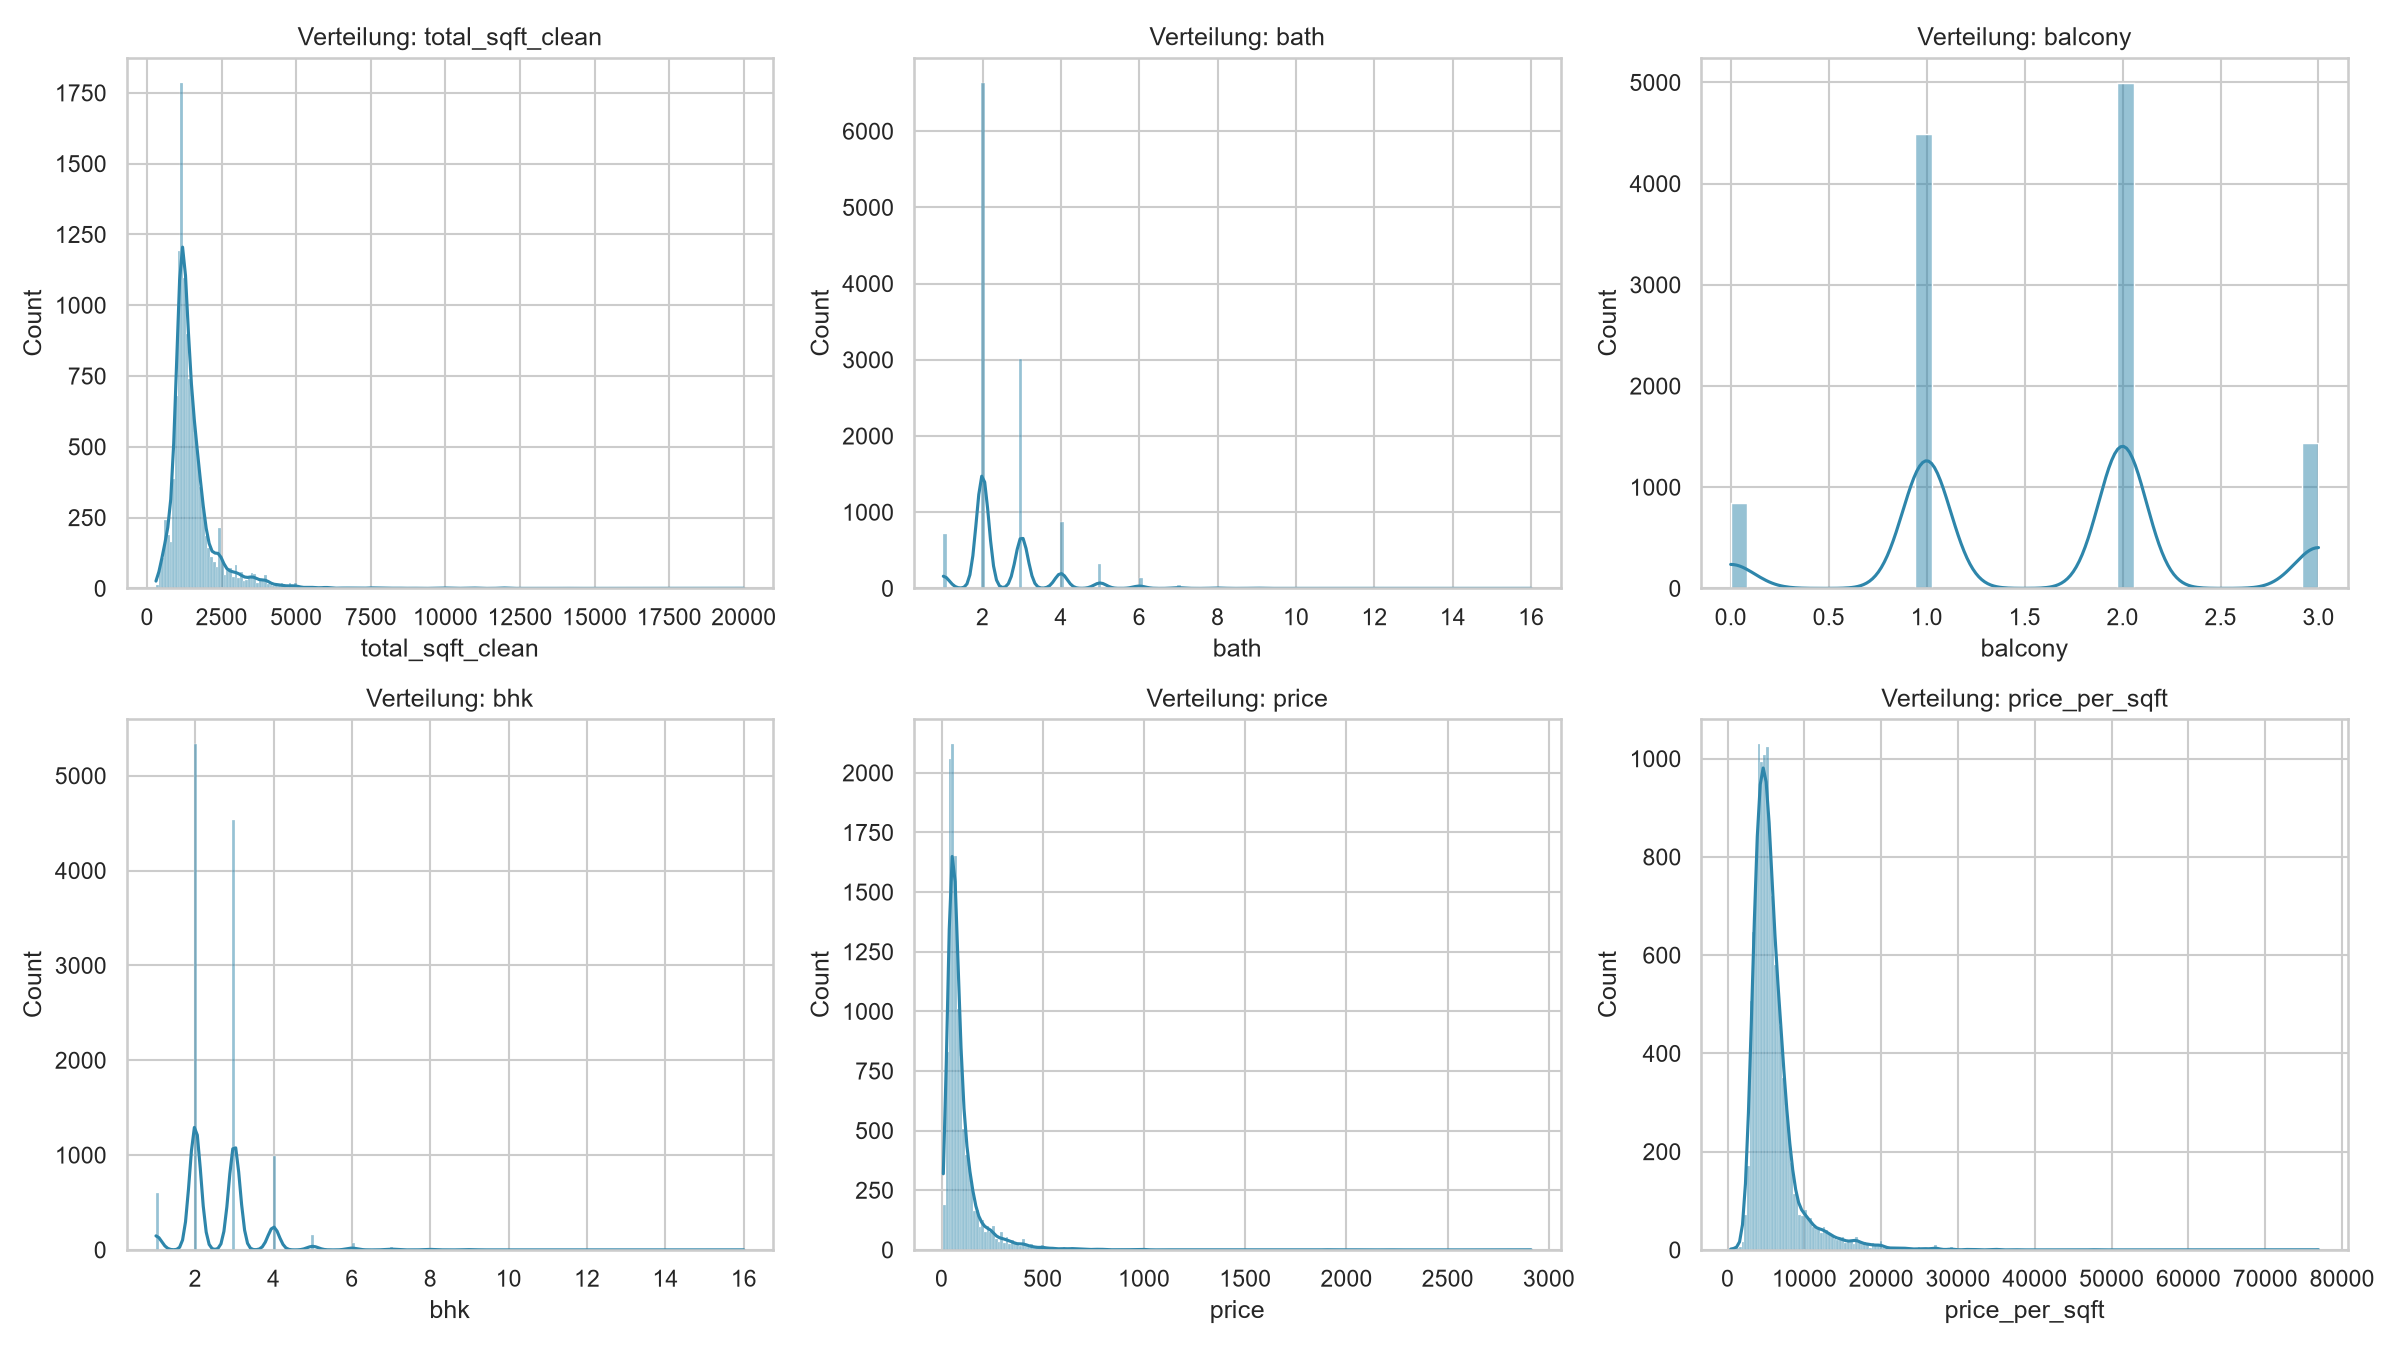

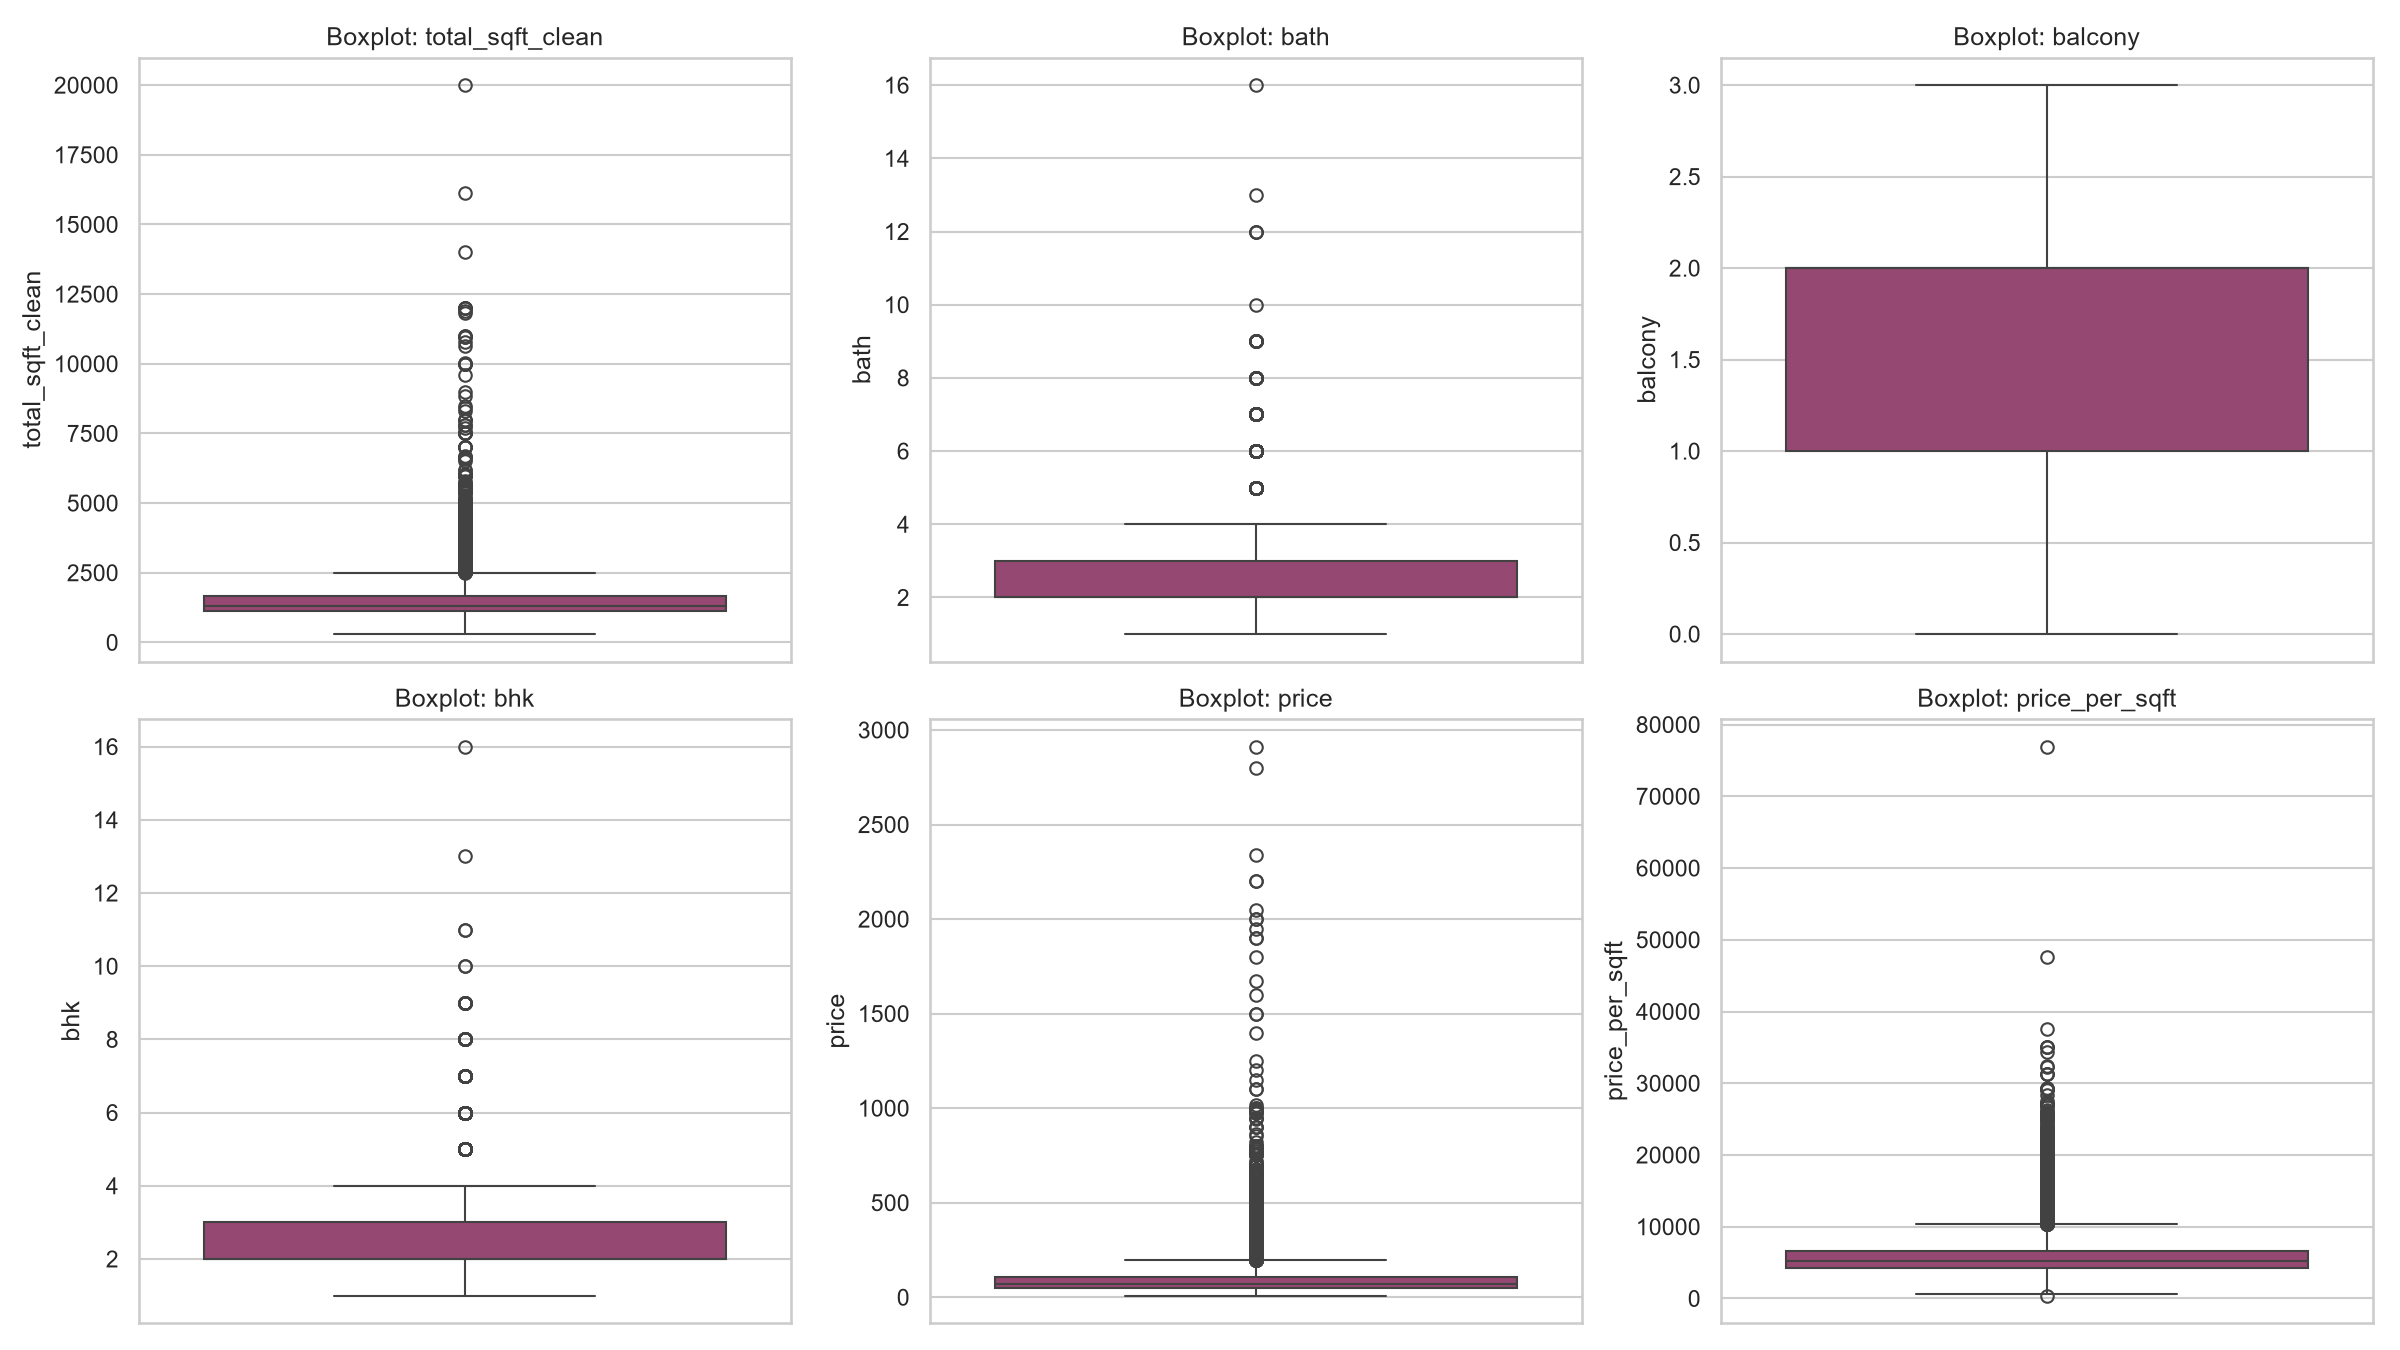

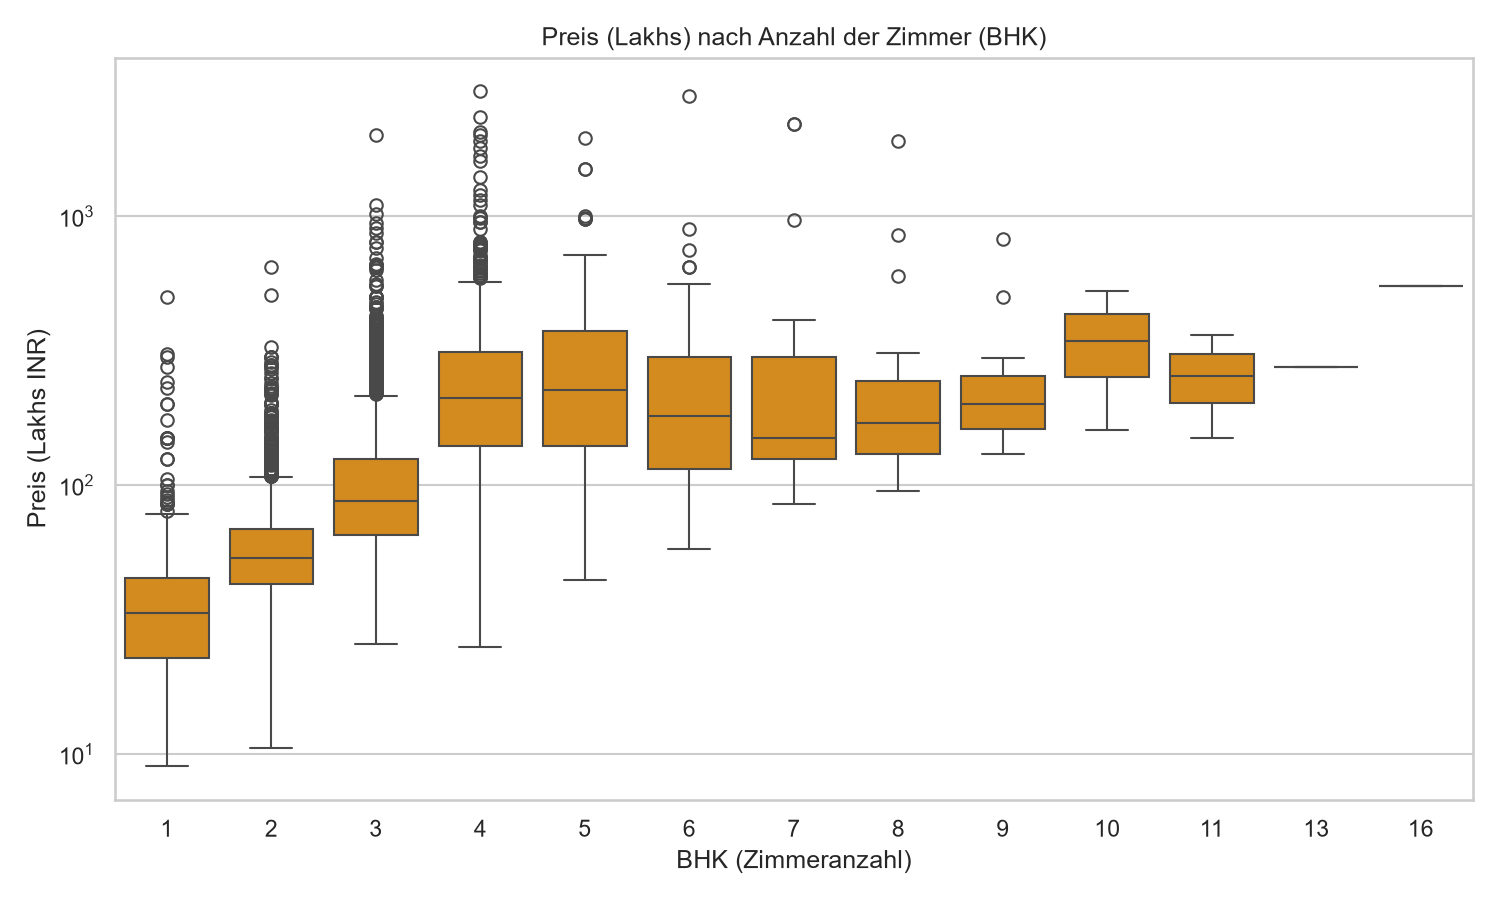

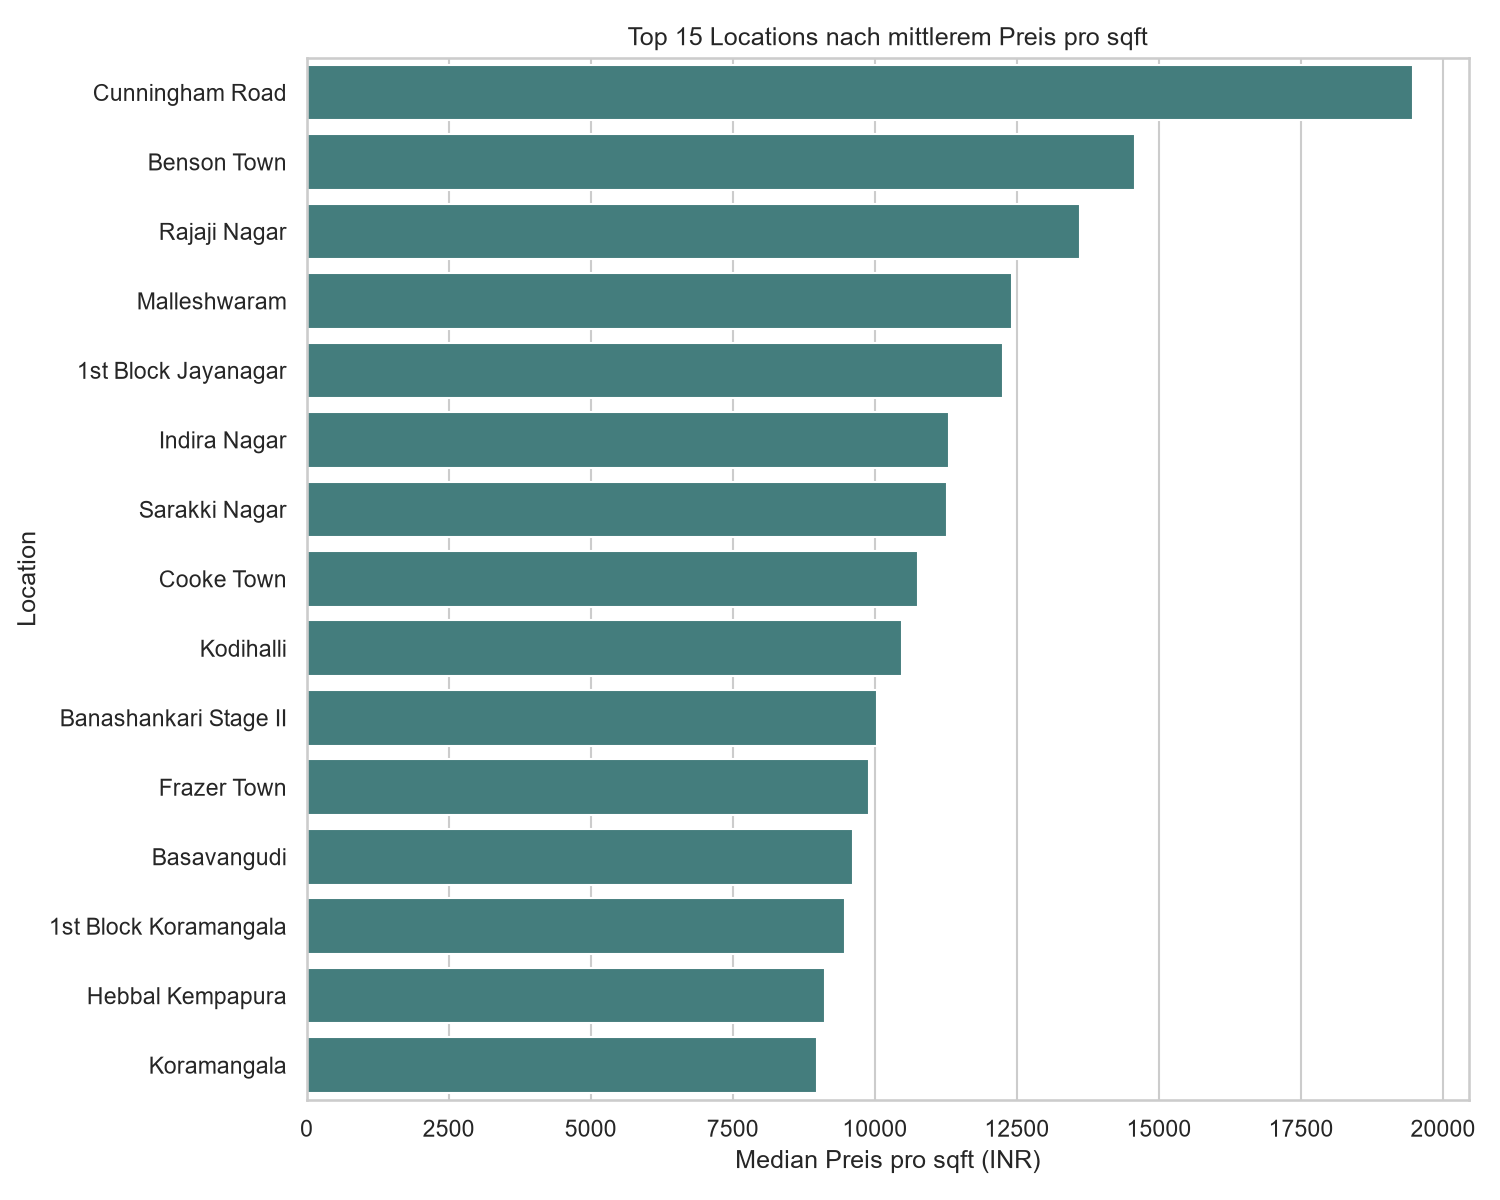

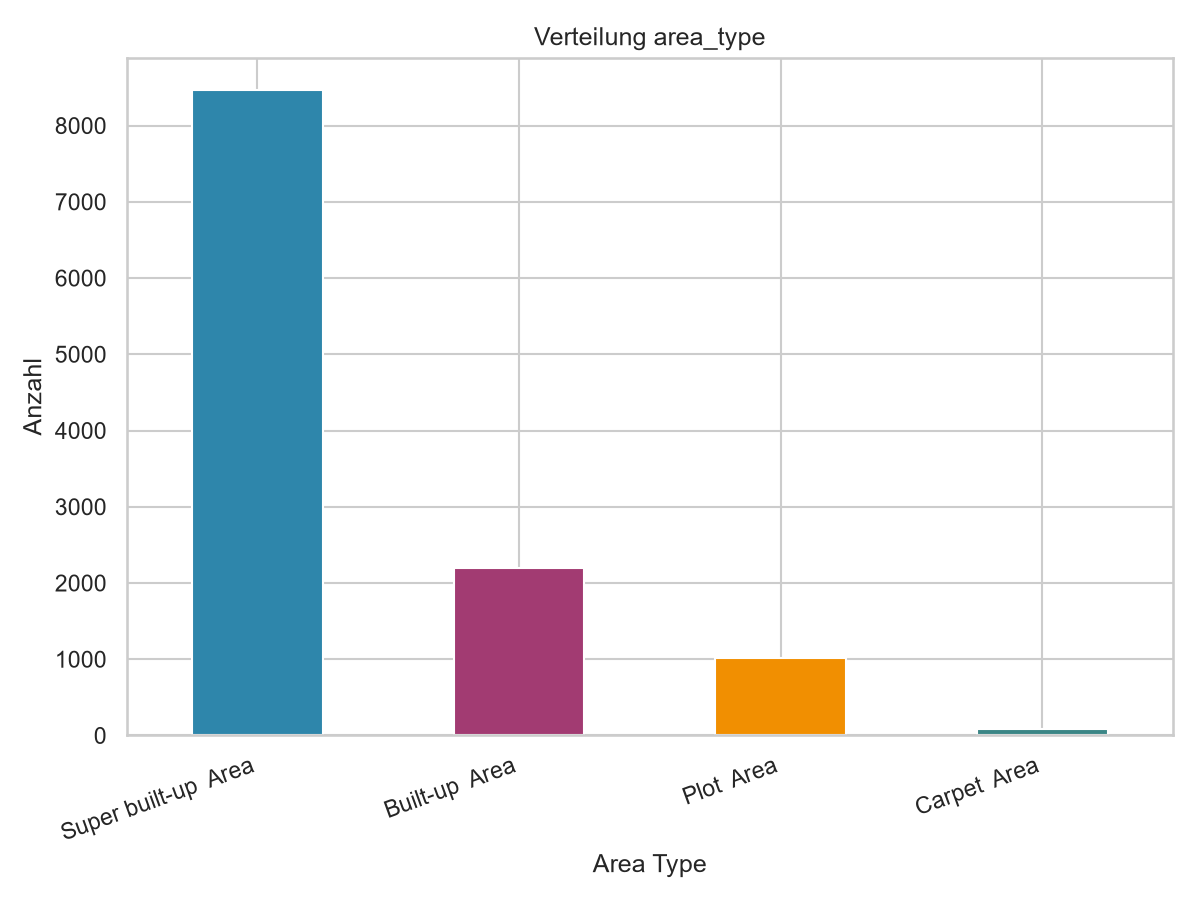

In [5]:
show('01_verteilungen_histogramme.png', '02_boxplots_ausreisser.png',
     '03_preis_nach_bhk.png', '04_top_locations_preis.png',
     '05_area_type_verteilung.png')

## Schritt 4: Einflussanalyse

In [6]:
step4 = load_step('04_einflussanalyse.py')
step4.main()

=== Schritt 4: Einflussanalyse ===

Zielvariable: price
Numerische Einflussvariablen: ['total_sqft_clean', 'bhk', 'bath', 'balcony']
Kategoriale Einflussvariablen: ['location_grouped', 'area_type']

--- Einzeleinfluss: numerische Variablen (Korrelation mit price) ---
           variable  pearson_r  pearson_p_value  spearman_r  spearman_p_value
0  total_sqft_clean     0.7203              0.0      0.8128               0.0
2              bath     0.5283              0.0      0.7026               0.0
1               bhk     0.4784              0.0      0.6686               0.0
3           balcony     0.1343              0.0      0.2360               0.0

--- Einzeleinfluss: kategoriale Variablen (ANOVA) ---
           variable  f_statistic  p_value  n_groups  signifikant (p<0.05)
0  location_grouped      11.5434      0.0       226                  True
1         area_type     276.1228      0.0         4                  True
📊 Gespeichert: 06_einzeleinfluss_scatterplots.png

--- Gemeinsame

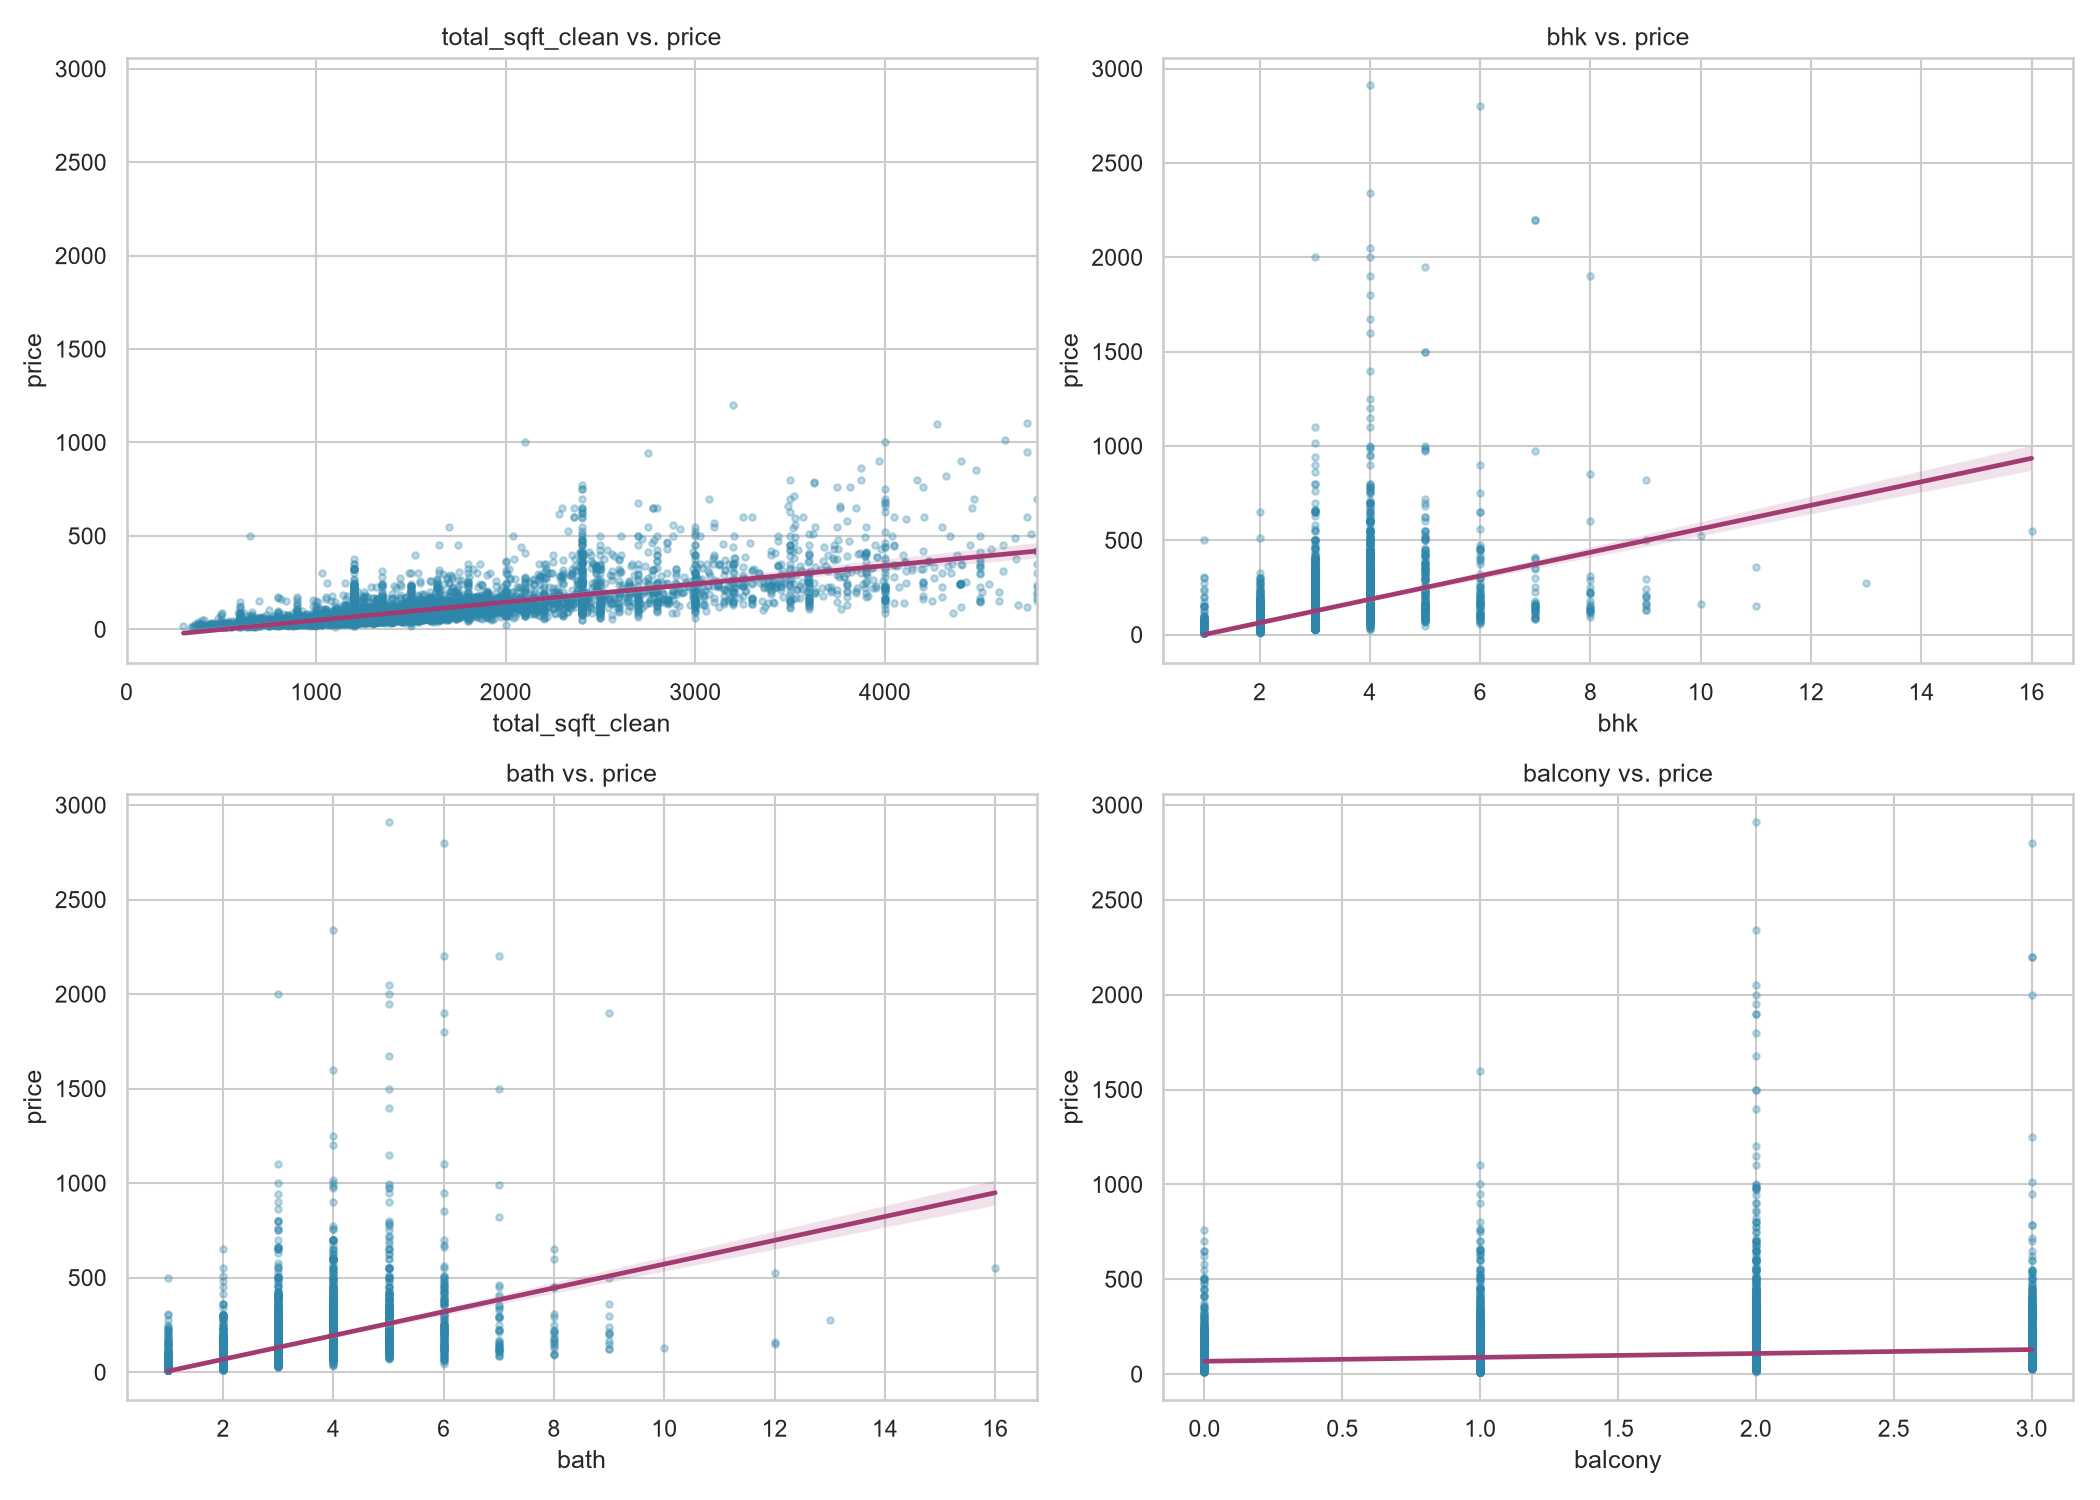

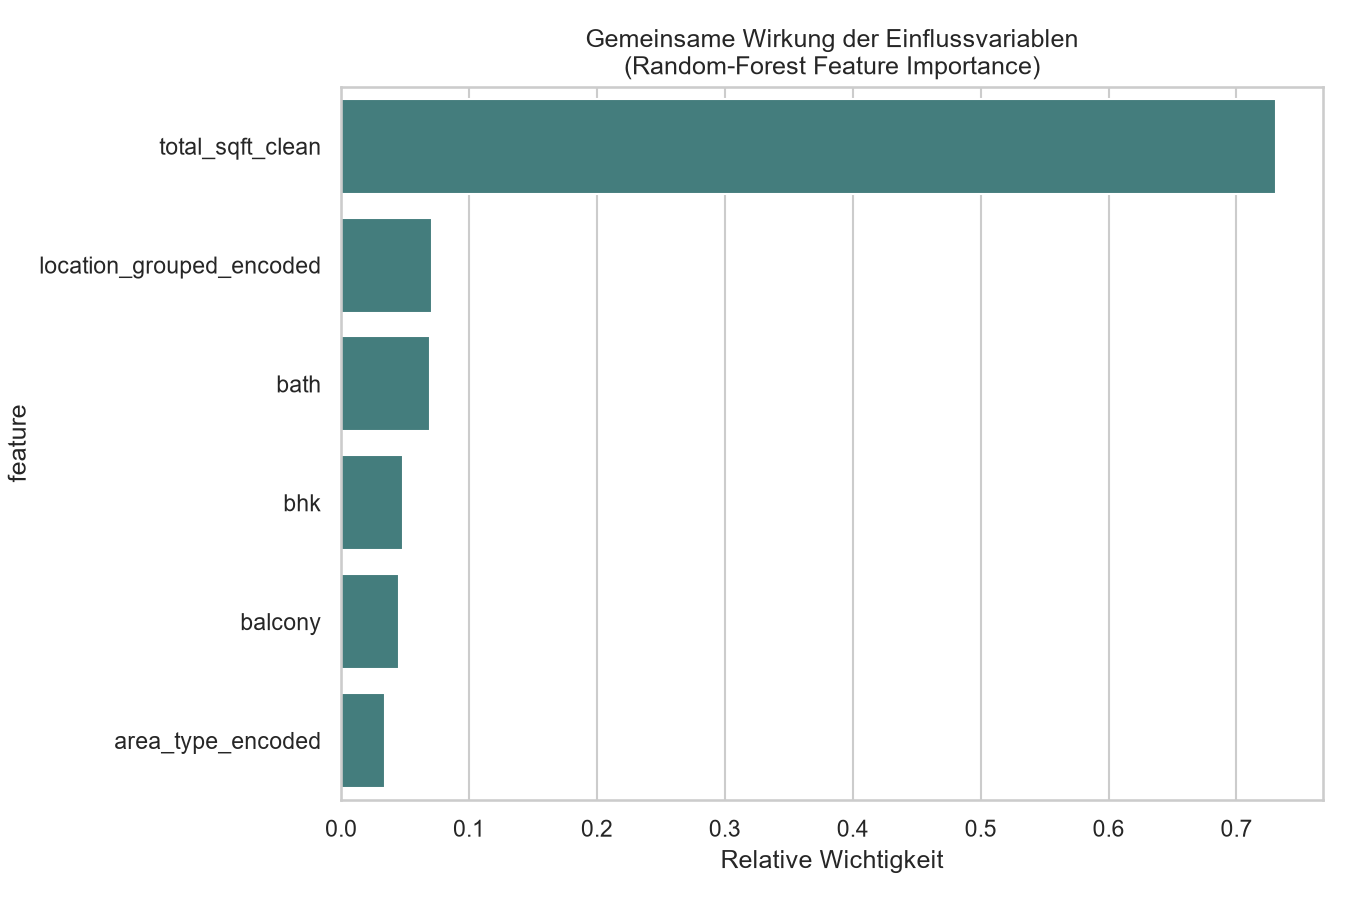

In [7]:
show('06_einzeleinfluss_scatterplots.png', '07_feature_importance.png')

## Schritt 5: Zusammenhangsanalyse

In [8]:
step5 = load_step('05_zusammenhangsanalyse.py')
step5.main()

=== Schritt 5: Zusammenhangsanalyse ===

--- Pearson-Korrelationsmatrix ---
                  total_sqft_clean    bhk   bath  balcony  price  \
total_sqft_clean             1.000  0.660  0.689    0.209  0.720   
bhk                          0.660  1.000  0.868    0.256  0.478   
bath                         0.689  0.868  1.000    0.250  0.528   
balcony                      0.209  0.256  0.250    1.000  0.134   
price                        0.720  0.478  0.528    0.134  1.000   
price_per_sqft               0.307  0.283  0.332    0.042  0.727   

                  price_per_sqft  
total_sqft_clean           0.307  
bhk                        0.283  
bath                       0.332  
balcony                    0.042  
price                      0.727  
price_per_sqft             1.000  
📊 Gespeichert: 08_korrelation_pearson.png

--- Spearman-Korrelationsmatrix ---
                  total_sqft_clean    bhk   bath  balcony  price  \
total_sqft_clean             1.000  0.809  0.782    0.3

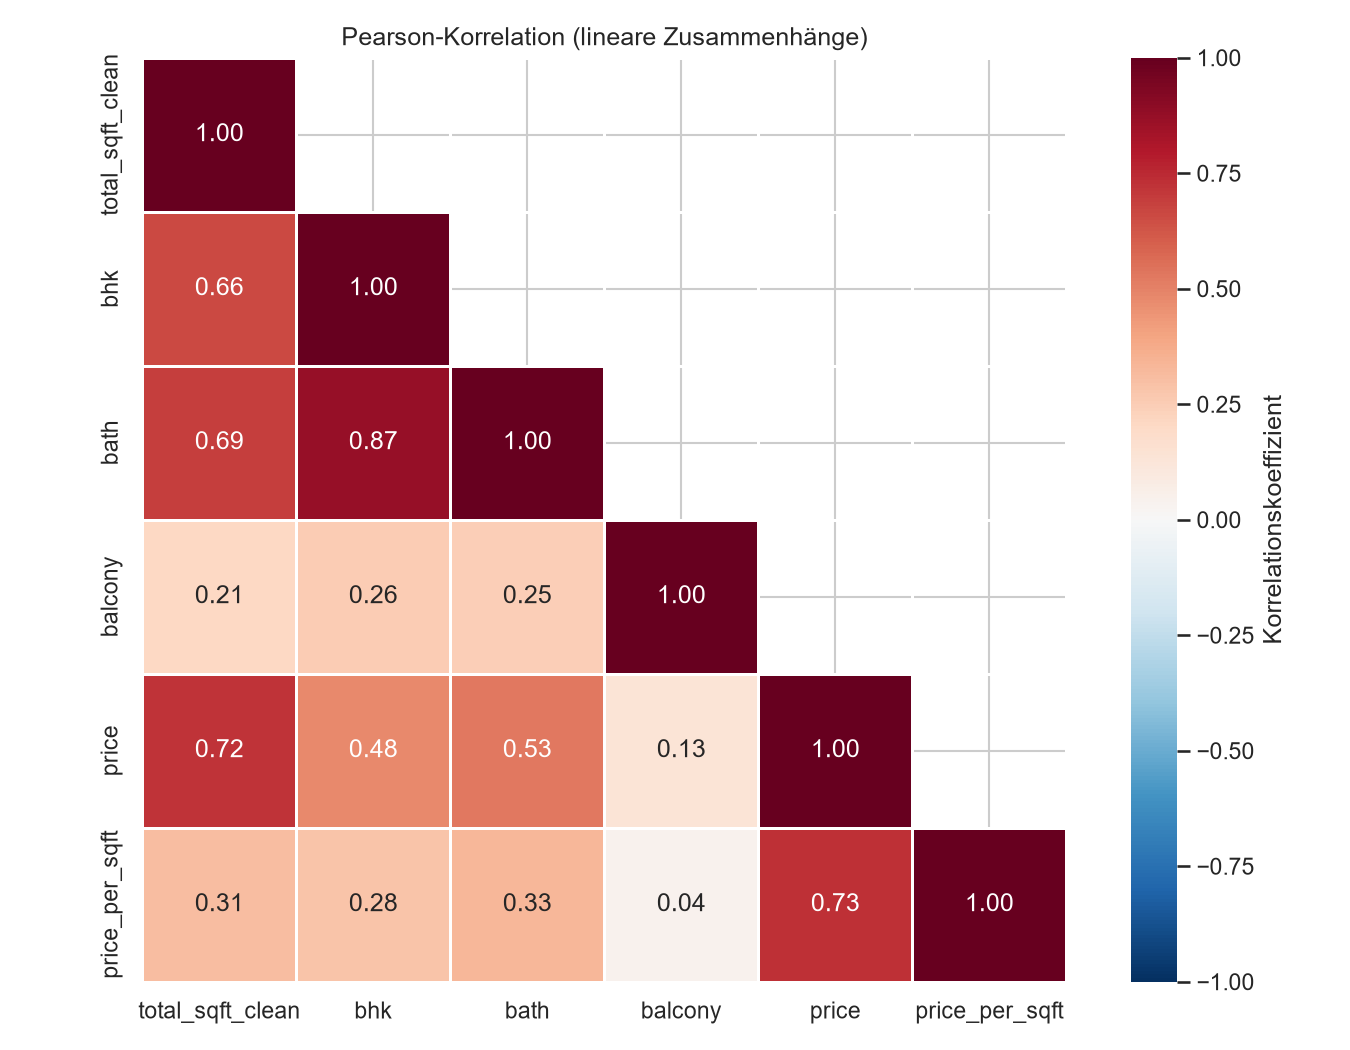

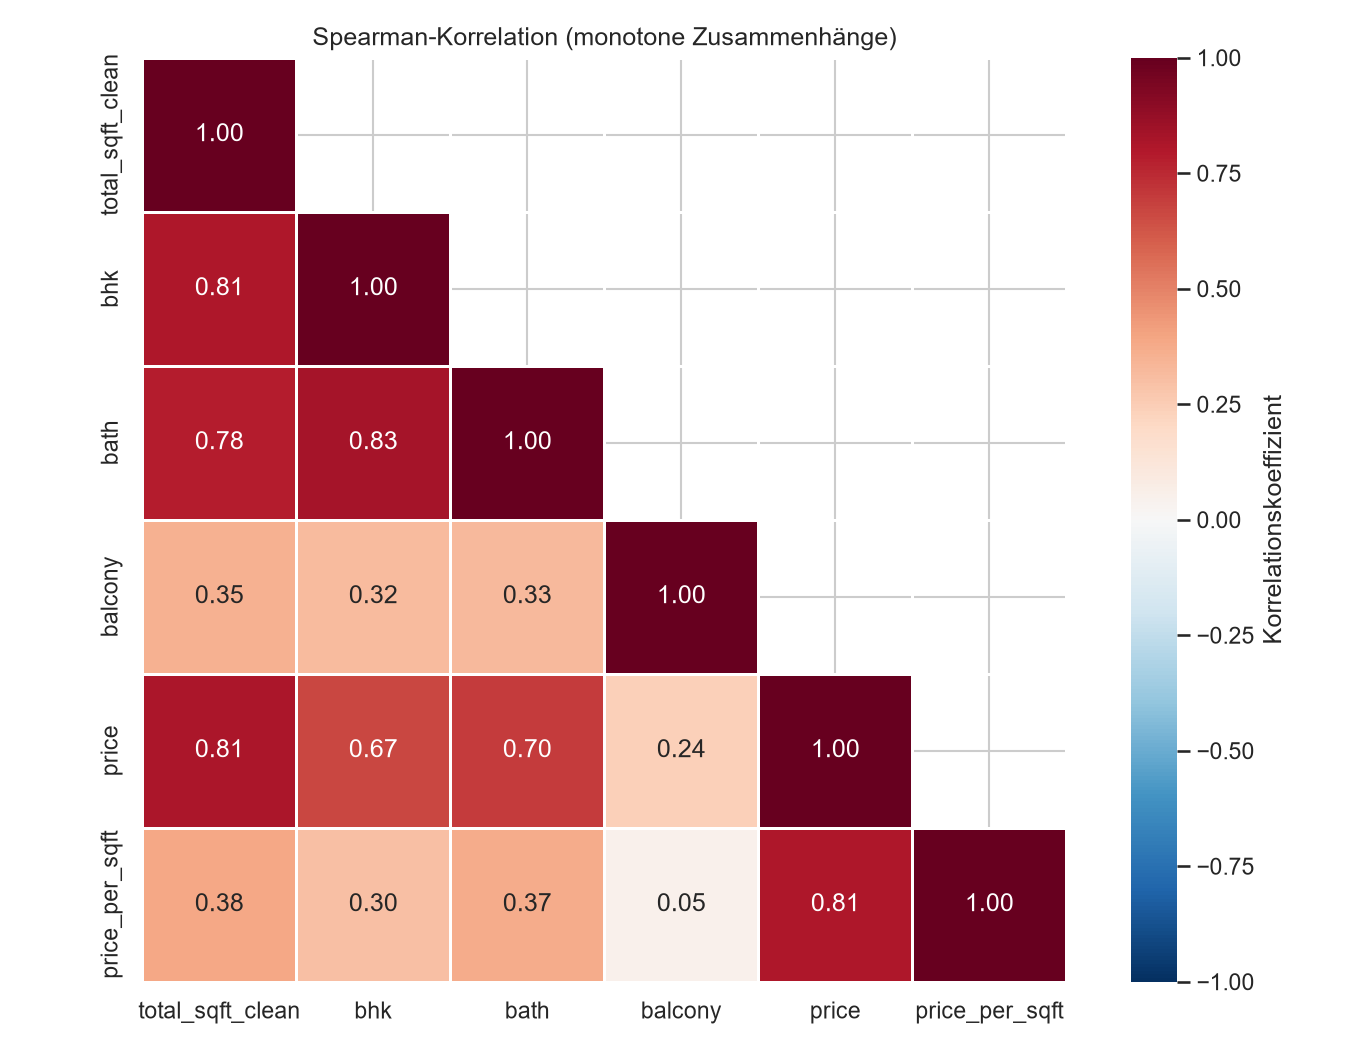

In [9]:
show('08_korrelation_pearson.png', '09_korrelation_spearman.png')

## Schritt 6: Hypothesentests und Inferenzstatistik

In [10]:
step6 = load_step('06_hypothesentests.py')
step6.main()

=== Schritt 6: Hypothesentests und Inferenzstatistik ===
Signifikanzniveau: α = 0.05


H1: Unterschied im Preis/sqft zwischen 'Ready To Move' und 'Im Bau'
H0: Es gibt keinen Unterschied im mittleren price_per_sqft zwischen
    fertigen und im Bau befindlichen Immobilien (μ1 = μ2).
H1: Es gibt einen Unterschied (μ1 ≠ μ2).

Stichprobengrößen: Ready To Move n=9207, Im Bau n=2551

Voraussetzungsprüfung:
  Shapiro-Wilk-Test (Ready To Move): W=0.7195, p=0.0000 -> NICHT normalverteilt (auf Stichprobenbasis)
  Shapiro-Wilk-Test (Im Bau): W=0.7420, p=0.0000 -> NICHT normalverteilt (auf Stichprobenbasis)

Levene-Test auf Varianzgleichheit: p=0.0000 -> Varianzen ungleich

Welch's t-Test: t = 7.1592, p = 0.000000
Mittelwert 'Ready To Move': 6057.50 INR/sqft
Mittelwert 'Im Bau':        5601.72 INR/sqft

✅ Ergebnis: p < 0.05 -> H0 wird abgelehnt.
   Es besteht ein statistisch signifikanter Unterschied im Preis/sqft
   zwischen fertigen und im Bau befindlichen Immobilien.

H2: Unterschied im Preis/sq

## Schritt 7: Machine Learning – Regressionsmodelle (verpflichtend)\n\n*Vergleich von Linearer Regression, Ridge, Random Forest und Gradient Boosting zur Vorhersage von `price`. Verwendet Robust Scaling für die numerischen Features (siehe Diskussion zur Skalierungswahl).*

In [11]:
step7 = load_step('07_regression_modelle.py')
step7.main()

=== Schritt 7: Machine Learning - Regressionsmodelle ===

Zielvariable: price (Preis in Lakhs INR)
Features (6): ['total_sqft_clean', 'bhk', 'bath', 'balcony', 'location_grouped', 'area_type']
Gesamtdatensatz: 11758 Zeilen

Trainingsdaten: 9406 Zeilen, Testdaten: 2352 Zeilen (80/20-Split)

--- Training: Lineare Regression ---
  CV R²:  0.5537 (± 0.1139)
  Test R²:   0.5960
  Test MAE:  32.50 Lakhs
  Test RMSE: 79.82 Lakhs

--- Training: Ridge-Regression ---
  CV R²:  0.5542 (± 0.1139)
  Test R²:   0.5971
  Test MAE:  32.39 Lakhs
  Test RMSE: 79.72 Lakhs

--- Training: Random Forest ---
  CV R²:  0.5830 (± 0.0616)
  Test R²:   0.5747
  Test MAE:  29.18 Lakhs
  Test RMSE: 81.91 Lakhs

--- Training: Gradient Boosting ---
  CV R²:  0.6058 (± 0.0555)
  Test R²:   0.5781
  Test MAE:  29.33 Lakhs
  Test RMSE: 81.58 Lakhs


--- Modellvergleich (sortiert nach Test R²) ---
            Modell  CV R² (Mittelwert)  CV R² (Std.abw.)  Test R²  Test MAE (Lakhs)  Test RMSE (Lakhs)
  Ridge-Regression   

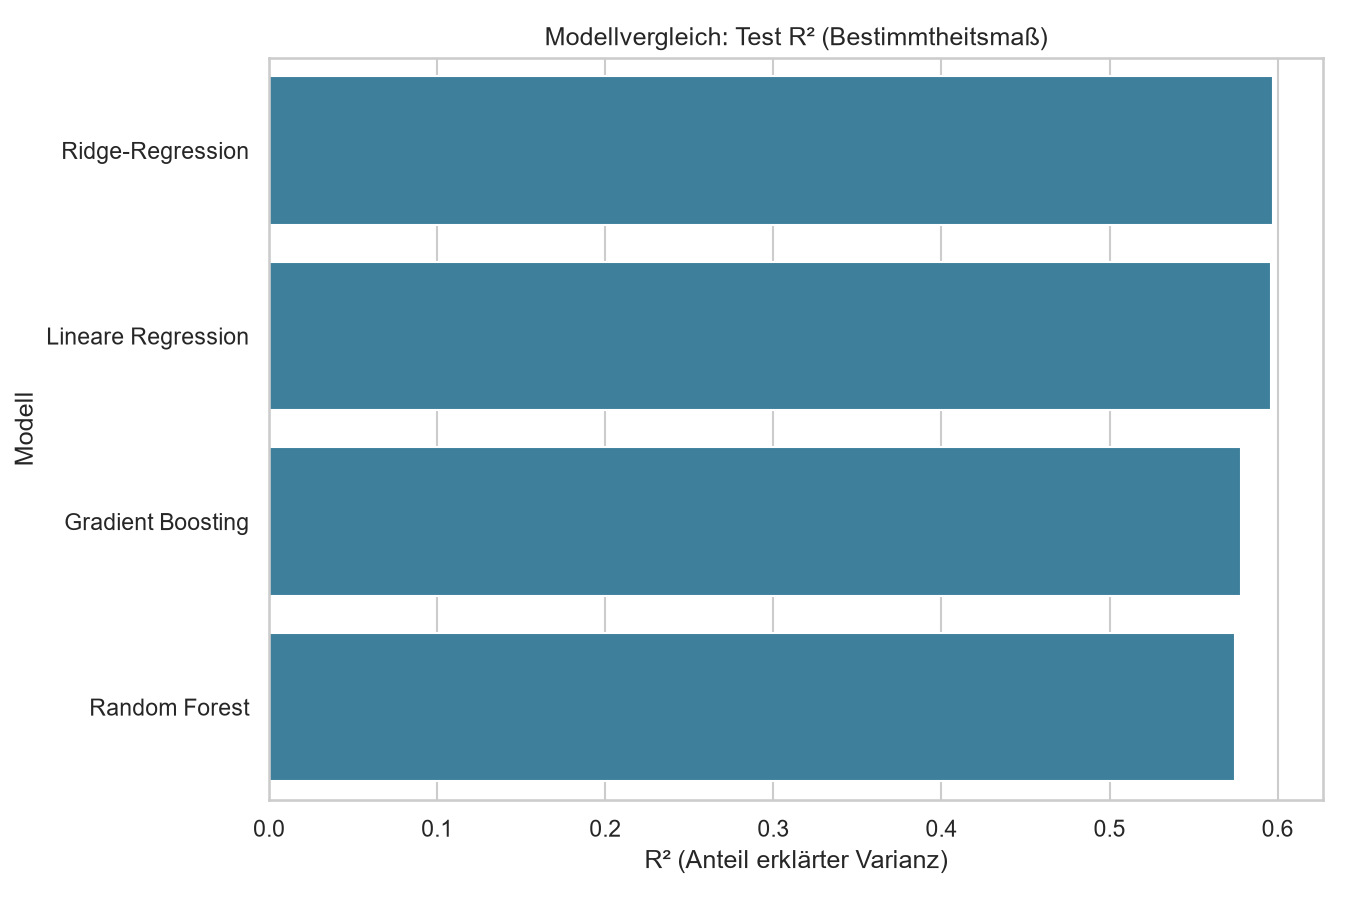

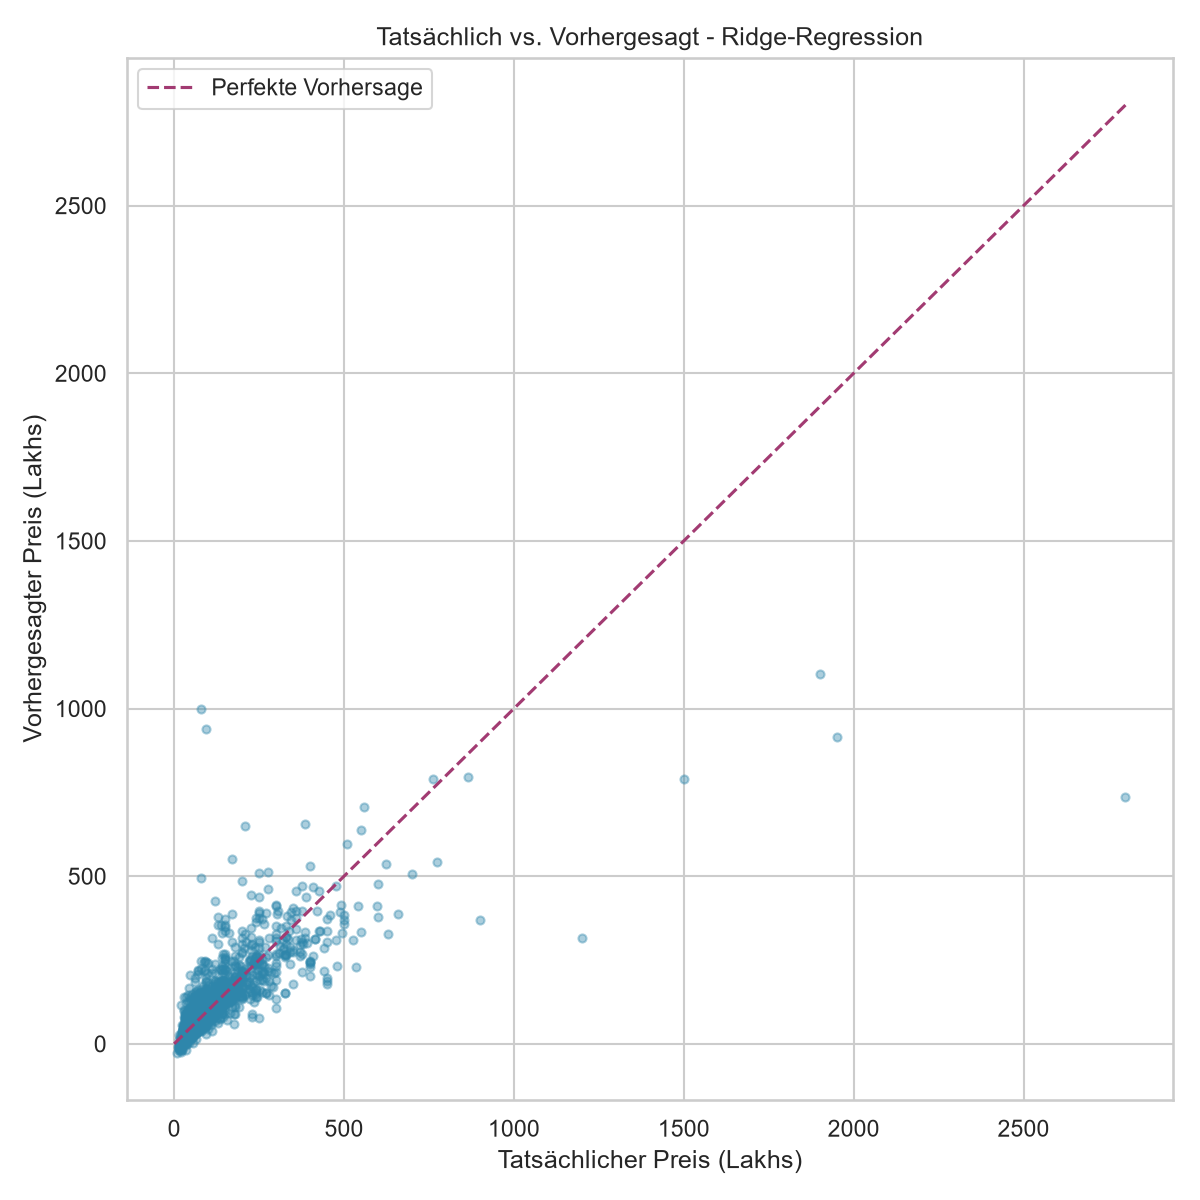

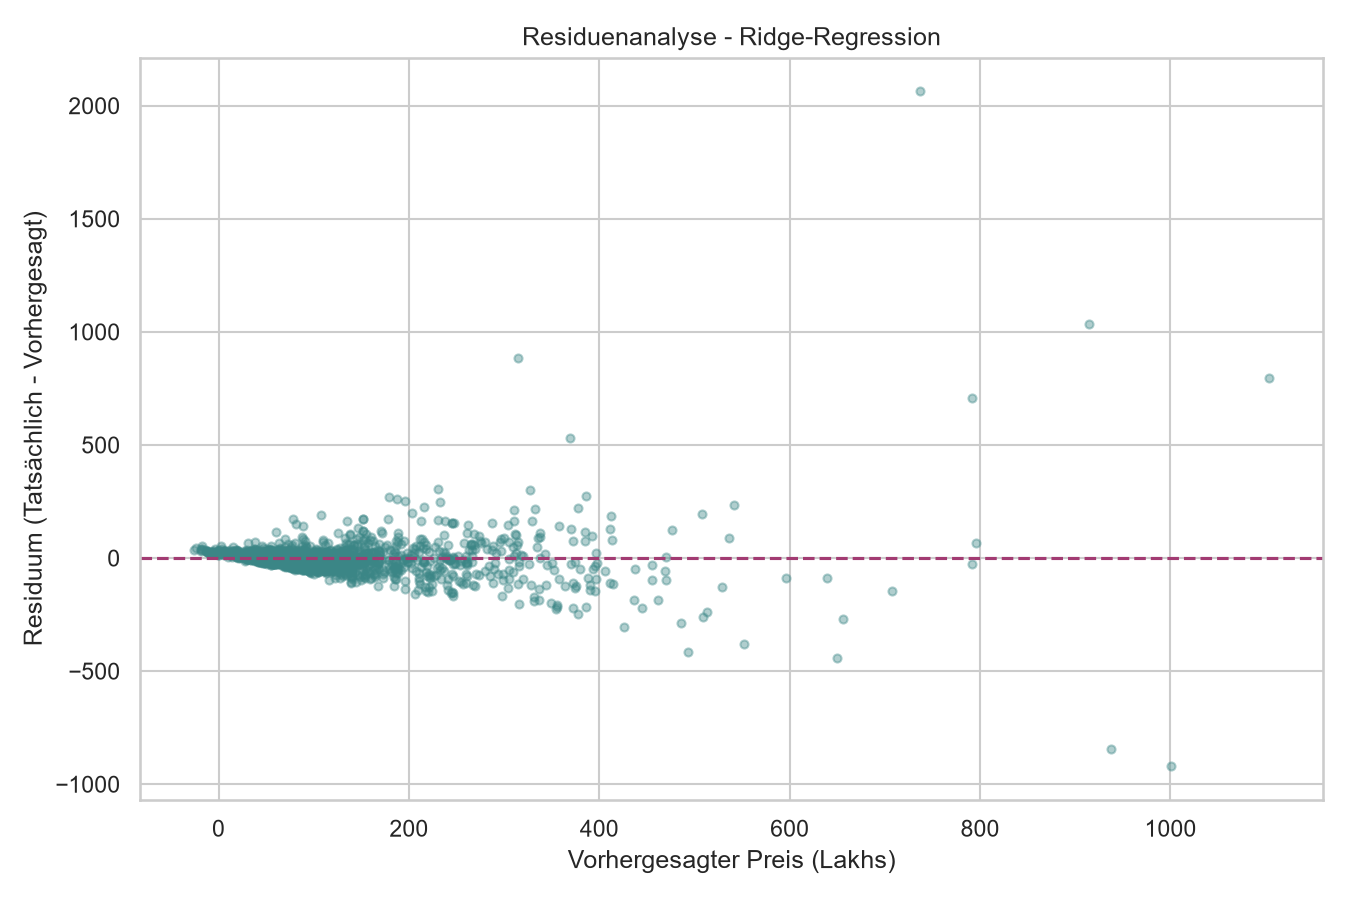

In [12]:
show('10_modellvergleich_r2.png', '11_tatsaechlich_vs_vorhergesagt.png',
     '12_residuenanalyse.png')

## Schritt 8: Klassifikation (Bonus)\n\n*Einteilung von `price` in drei Kategorien (cheap/medium/expensive) und Vergleich von Logistischer Regression und Decision Tree Classifier.*

In [13]:
step8 = load_step('08_klassifikation.py')
step8.main()

=== Schritt 8: Klassifikation (Bonus) ===

Klassengrenzen: cheap <= 55.0 Lakhs < medium <= 89.0 Lakhs < expensive

Klassenverteilung:
price_category
cheap        4159
expensive    3903
medium       3696
Name: count, dtype: int64

Trainingsdaten: 9406 Zeilen, Testdaten: 2352 Zeilen (80/20-Split, stratifiziert nach Klasse)

--- Training: Logistische Regression ---
  CV Accuracy: 0.7581 (± 0.0103)
  Test Accuracy:  0.7674
  Test Precision (macro): 0.7630
  Test Recall (macro):    0.7634
  Test F1-Score (macro):  0.7629

  Klassifikationsbericht:
              precision    recall  f1-score   support

       cheap       0.79      0.83      0.81       832
      medium       0.65      0.62      0.64       739
   expensive       0.84      0.83      0.84       781

    accuracy                           0.77      2352
   macro avg       0.76      0.76      0.76      2352
weighted avg       0.77      0.77      0.77      2352


--- Training: Decision Tree ---
  CV Accuracy: 0.7249 (± 0.0163)
  Te

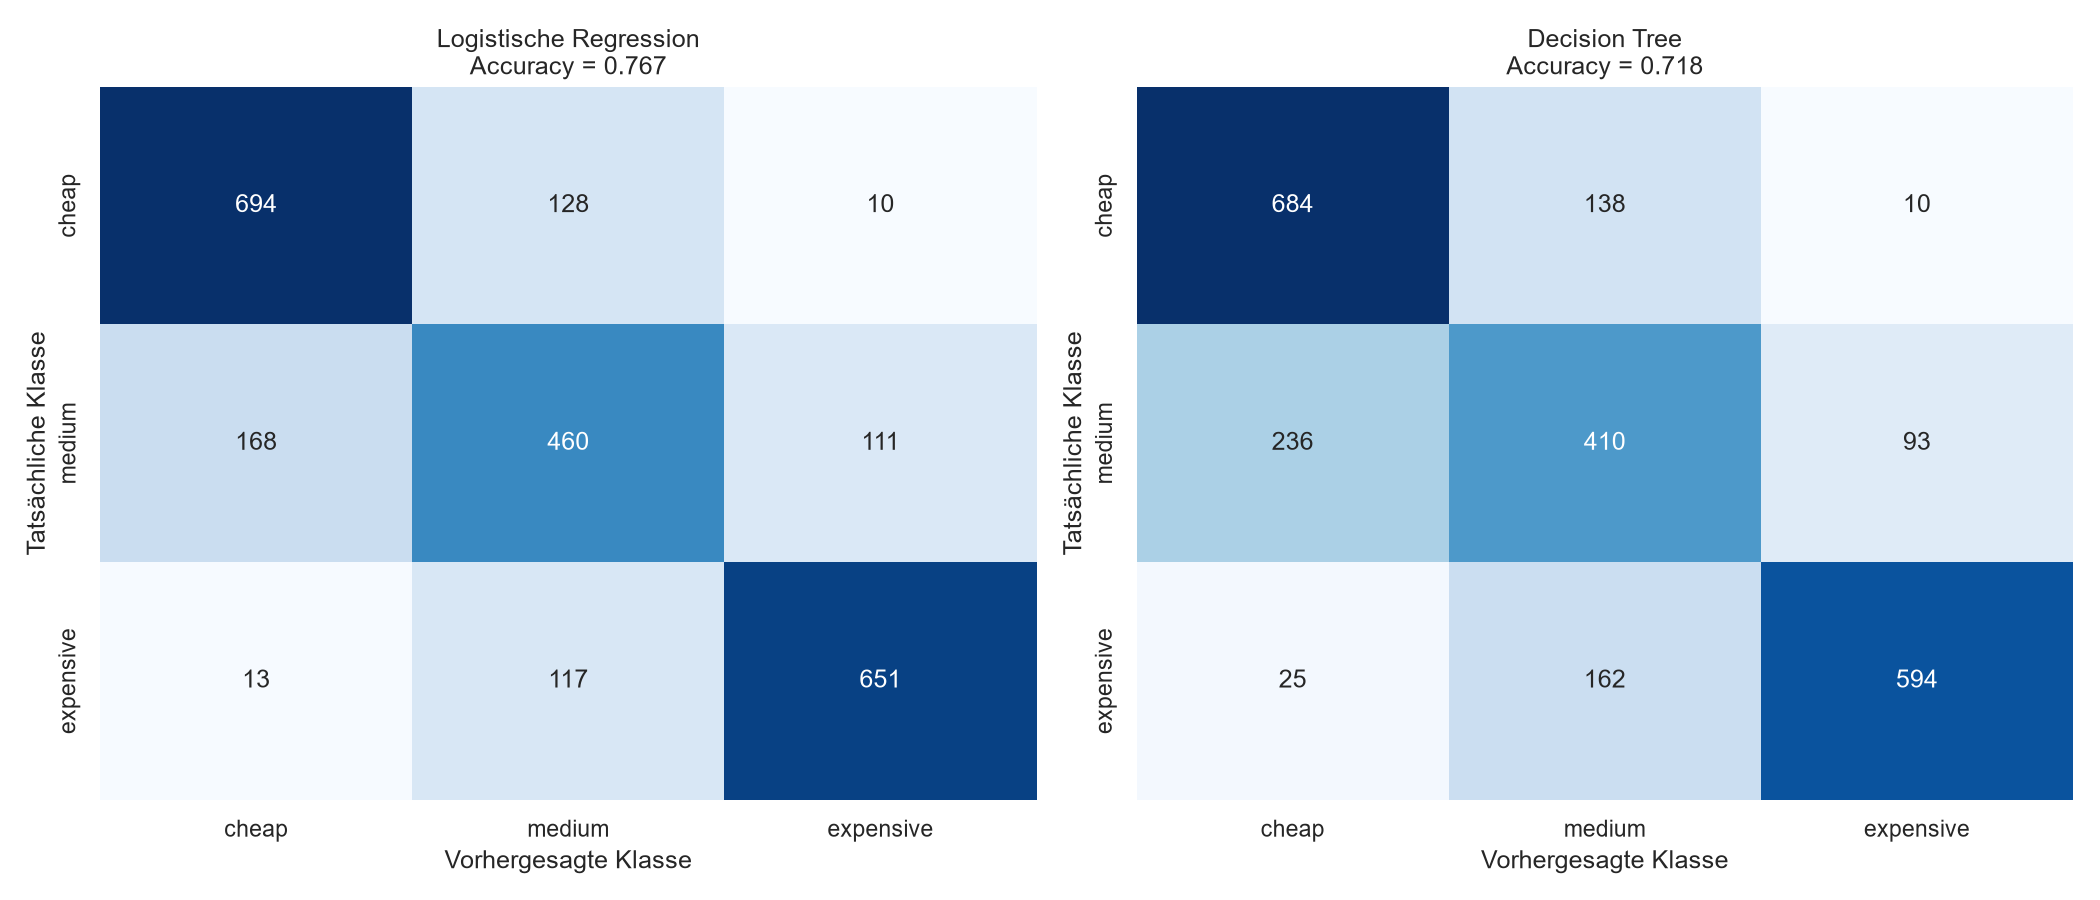

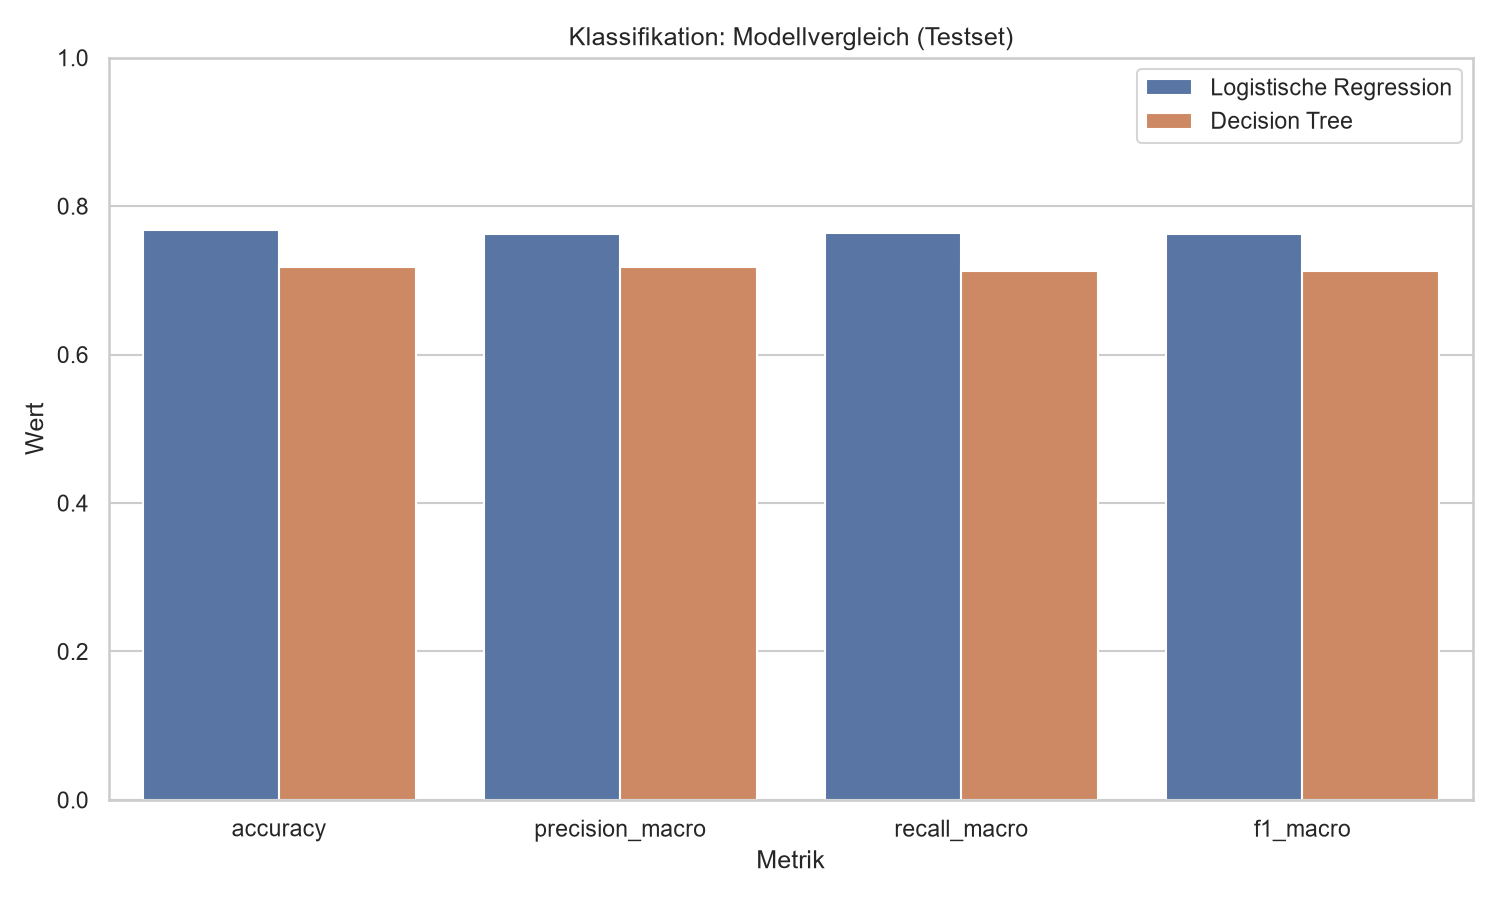

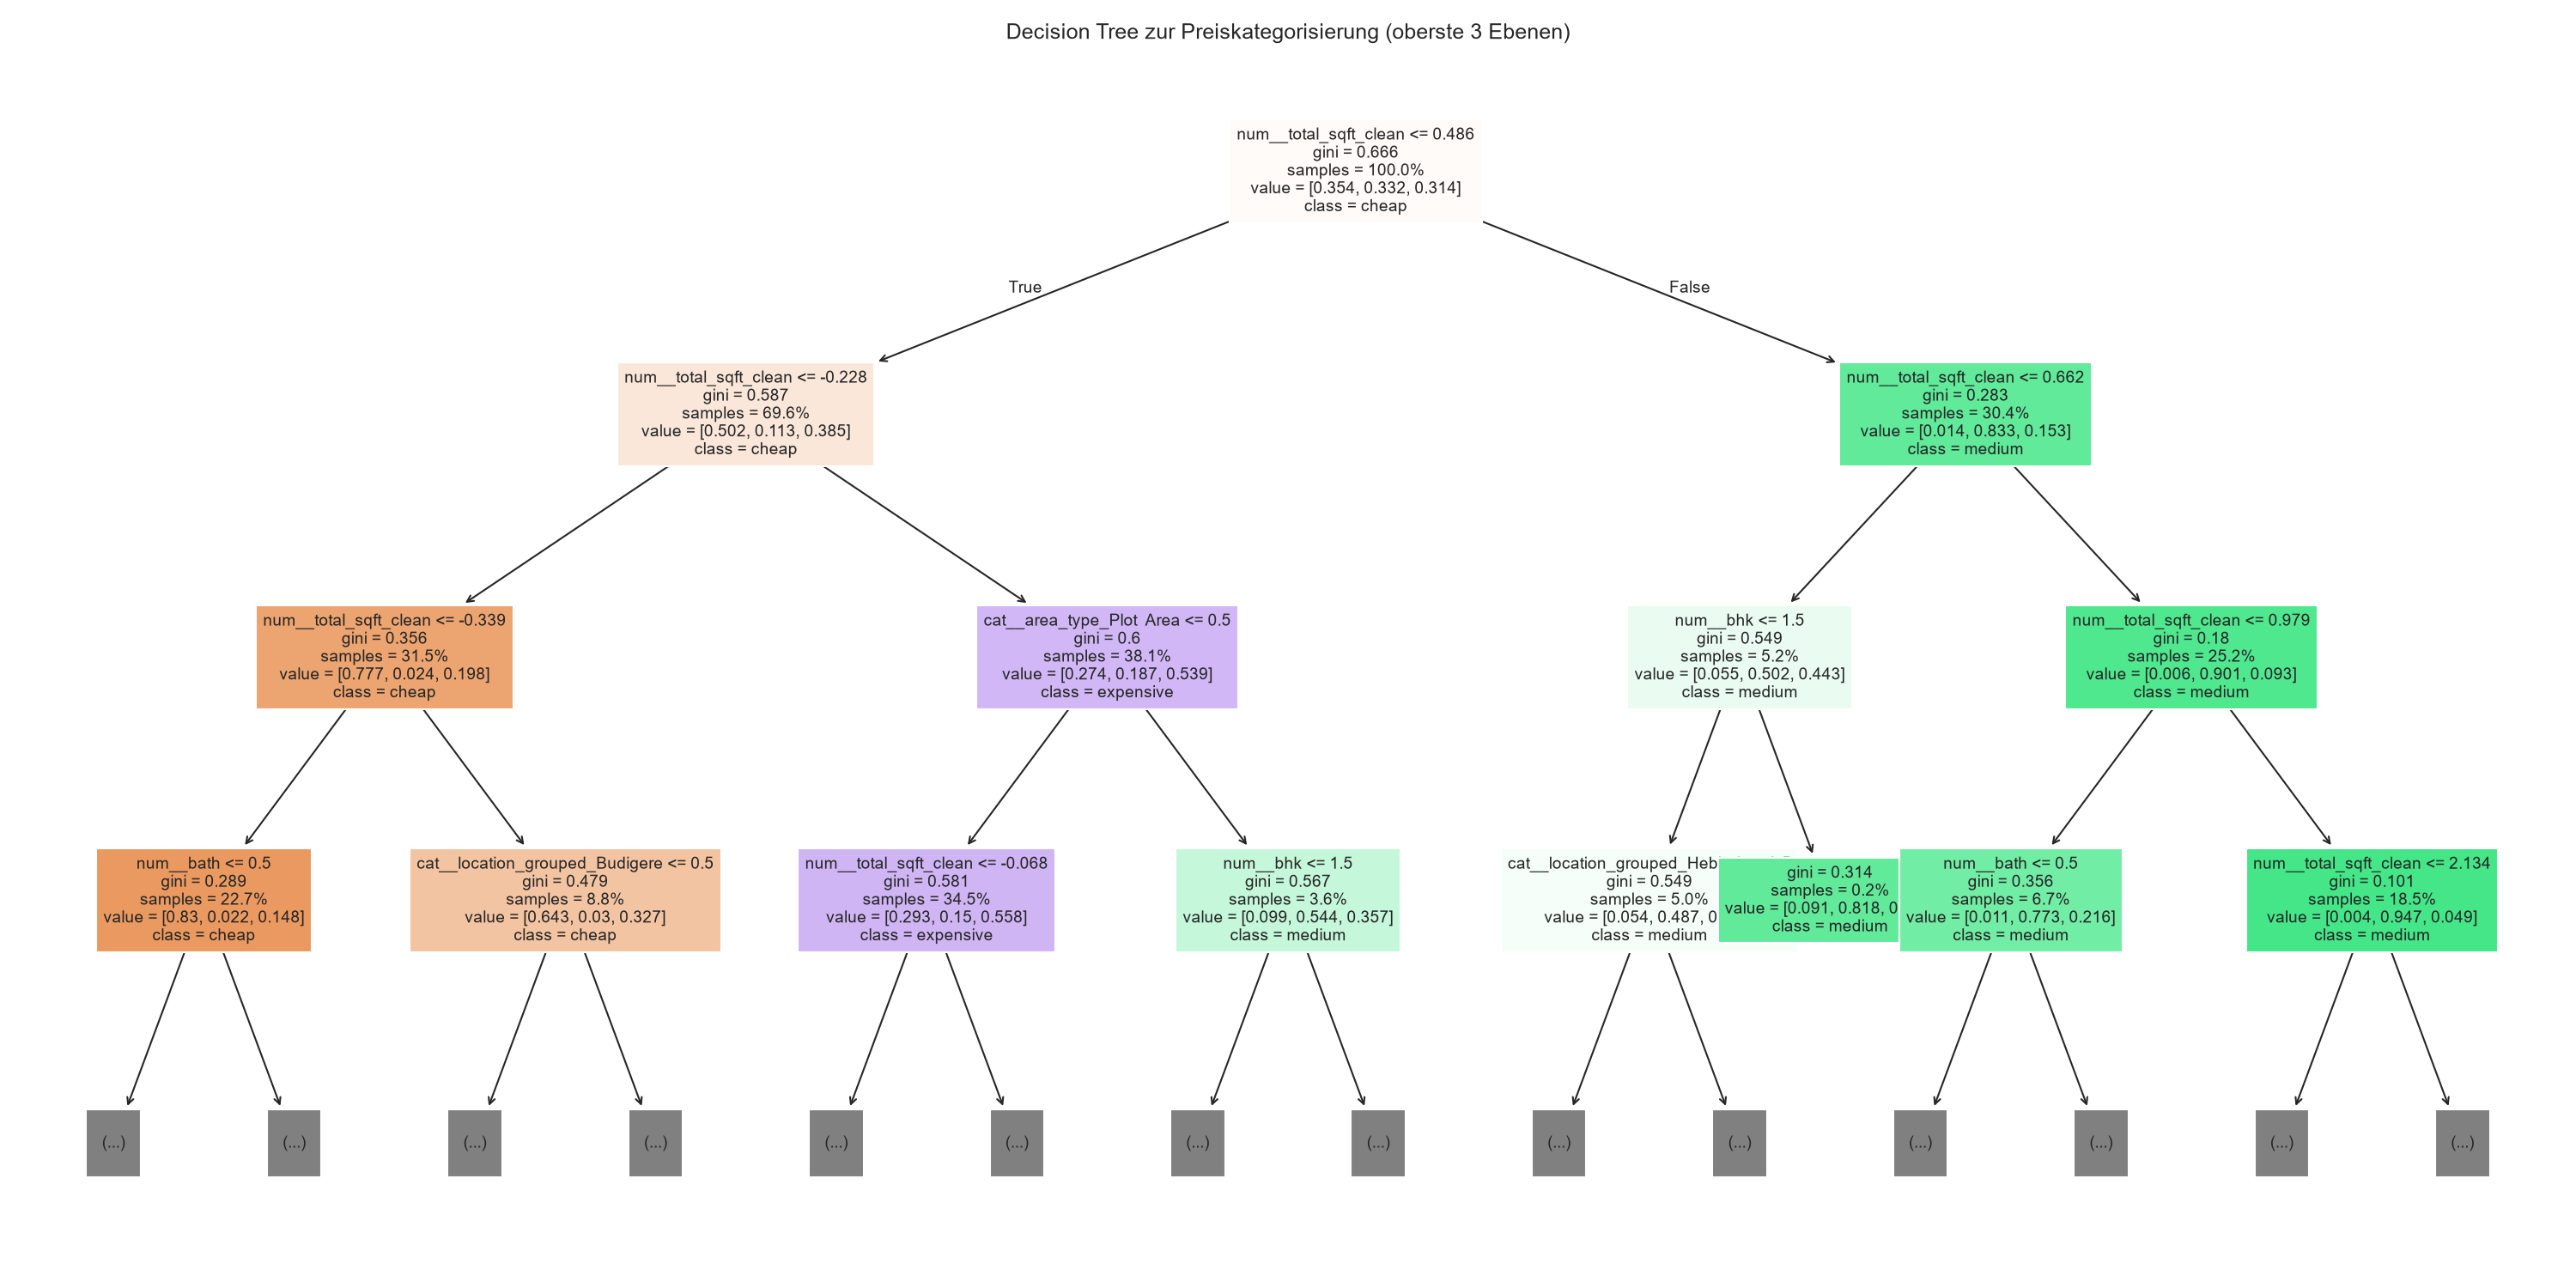

In [14]:
show('13_klassifikation_confusion_matrices.png',
     '14_klassifikation_modellvergleich.png',
     '15_decision_tree_visualisierung.png')

## Schritt 9: Beispiel-Kundenanfrage (E-Mail-Simulation)\n\n*Erstellung einer Test-E-Mail mit frei erfundenen Daten, in der ein fiktiver Interessent nach dem Preis einer Immobilie mit bestimmten Eigenschaften fragt. Es werden ausschließlich Testdaten verwendet, keine echten Kundendaten (siehe Datenschutz-Hinweis in der Aufgabendefinition).*

In [15]:
step9 = load_step('09_email_simulation.py')
step9.main()

=== Schritt 9: Beispiel-Kundenanfrage (E-Mail-Simulation) ===

Hinweis: Es werden ausschliesslich Testdaten verwendet, keine
echten Kundendaten (siehe Aufgabendefinition, 'Wichtiger Hinweis').

Beispiel-E-Mail erstellt: d:\learning\hsh2\final_project\DataScienceProjekt\output/beispiel_kundenanfrage.txt

--- Inhalt der erzeugten Test-E-Mail ---

Von: Anil Kumar <test.kunde@beispiel-mail.invalid>
An: info@yay-studios-real-estate.invalid
Betreff: Preisanfrage fuer Immobilie in Whitefield
Datum: 23.06.2026, 10:26 Uhr

Sehr geehrtes Team,

ich interessiere mich fuer eine Immobilie und wuerde gerne eine
Preiseinschaetzung erhalten. Die Eckdaten sind wie folgt:

  - Lage: Whitefield
  - Flaechenart: Plot  Area
  - Wohnflaeche: 1500 sqft
  - Zimmeranzahl (BHK): 2
  - Anzahl Badezimmer: 2
  - Anzahl Balkone: 1

Koennten Sie mir bitte mitteilen, mit welchem ungefaehren Kaufpreis ich fuer
eine solche Immobilie rechnen muesste?

Vielen Dank im Voraus fuer Ihre Rueckmeldung.

Mit freundlichen Grues

## Schritt 10: Webinterface (Bonus - Interaktive Demo)

*Eine Streamlit-Anwendung zur Live-Preis- und Kategorie-Vorhersage.*

**Hinweis:** Dieser Schritt kann im Notebook nicht direkt ausgeführt werden.
Starten Sie stattdessen in der Kommandozeile aus dem `src/`-Ordner:

```bash
streamlit run 10_web_app.py
```

Das öffnet eine interaktive Weboberfläche mit:
- Eingabeformular für alle 6 Features
- Live Preis-Vorhersage (Regression)
- Live Preiskategorie-Vorhersage (Klassifikation)
- Modell-Vertrauen (Wahrscheinlichkeiten)
- Kontext-Informationen zur Lage


## Zusammenfassung

Alle Ergebnisse (Diagramme, Tabellen, die trainierten Modelle sowie die
Beispiel-E-Mail) liegen jetzt vollständig im Ordner `/output` vor und können
direkt in die Projektdokumentation bzw. die Abschlusspräsentation übernommen
werden.

Die optionale Webinterface (Schritt 10) stellt eine benutzerfreundliche
Schnittstelle zur Verfügung, um die trainierten Modelle interaktiv zu nutzen.